<a href="https://colab.research.google.com/github/cs24dse023-netizen/CSL701-cs23_Machine-Learning-Lab/blob/main/ML_exp_Exp_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Sandesh kaskar  Rollno: cs23


Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


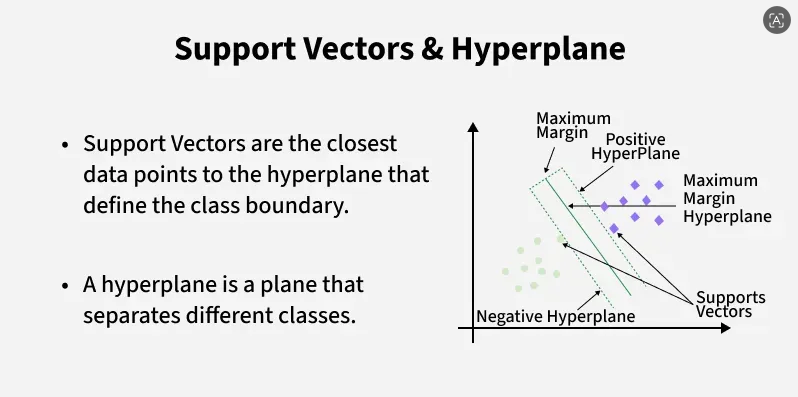
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Load Iris dataset
df = pd.read_csv("Iris.csv")

# Display first five rows
df.head()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


# Task 2: Explore the Dataset

Dataset Shape: (150, 6)

Column Names:
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Statistical Summary:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000



Missing Values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Class Distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


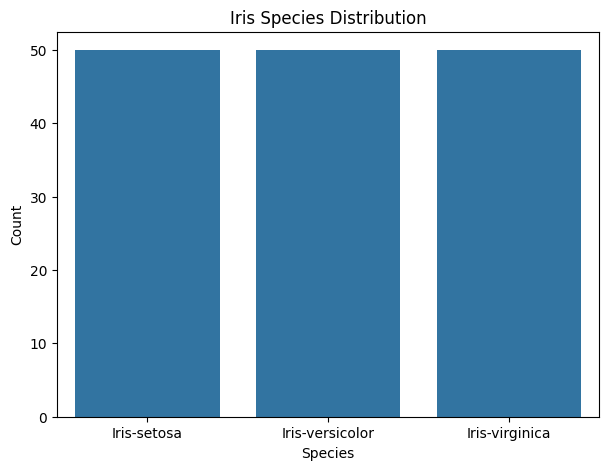

In [ ]:
# Display dataset information
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df["Species"].value_counts())


plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Species")
plt.title("Iris Species Distribution")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()



# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [ ]:
# Remove Id column
df = df.drop("Id", axis=1)

# Select features
X = df.drop("Species", axis=1)

# Select target
y = df["Species"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())


Features:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Target:


,Species
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Standardize the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 120
Testing samples: 30


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [ ]:
# Create Linear SVM model
svm_model = SVC(kernel="linear", random_state=42)

# Train the model
svm_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM Predictions:")
print(y_pred_svm)


SVM Predictions:
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa']


# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


Linear SVM Accuracy: 1.0
Linear SVM Accuracy: 100.00%


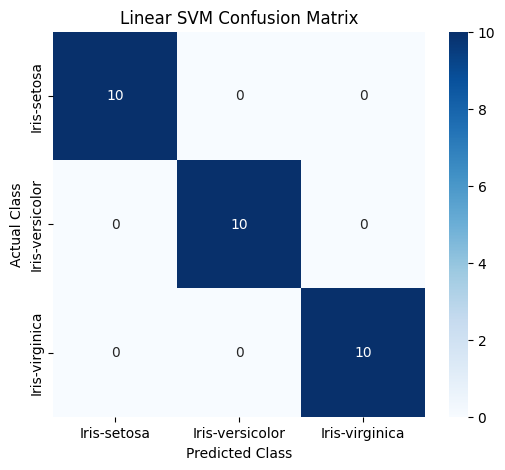

Linear SVM Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [ ]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("Linear SVM Accuracy:", svm_accuracy)
print("Linear SVM Accuracy: {:.2f}%".format(svm_accuracy * 100))


cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=svm_model.classes_,
    yticklabels=svm_model.classes_
)

plt.title("Linear SVM Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()


print("Linear SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))




# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

2-D Linear SVM Accuracy: 93.33%


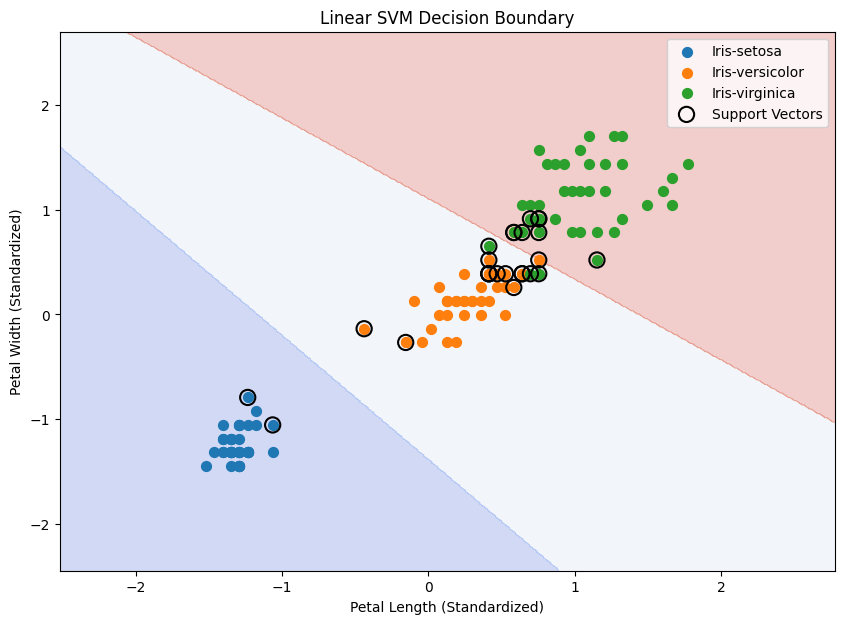

Number of Support Vectors: 25


In [ ]:
# Select two features
X_2d = df[["PetalLengthCm", "PetalWidthCm"]]
y_2d = df["Species"]

# Split the 2-D dataset
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d,
    y_2d,
    test_size=0.2,
    random_state=42,
    stratify=y_2d
)

# Scale the two features
scaler_2d = StandardScaler()

X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

# Train Linear SVM
svm_2d = SVC(kernel="linear", random_state=42)
svm_2d.fit(X_train_2d_scaled, y_train_2d)

# Accuracy
y_pred_2d_svm = svm_2d.predict(X_test_2d_scaled)

print(
    "2-D Linear SVM Accuracy: {:.2f}%".format(
        accuracy_score(y_test_2d, y_pred_2d_svm) * 100
    )
)



# Create a mesh grid
x_min = X_train_2d_scaled[:, 0].min() - 1
x_max = X_train_2d_scaled[:, 0].max() + 1
y_min = X_train_2d_scaled[:, 1].min() - 1
y_max = X_train_2d_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Predict every point in the mesh
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = np.array([list(svm_2d.classes_).index(i) for i in Z])
Z = Z.reshape(xx.shape)

# Plot decision regions
plt.figure(figsize=(10, 7))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.25,
    cmap=plt.cm.coolwarm
)

# Plot training data
for i, species in enumerate(svm_2d.classes_):
    mask = y_train_2d == species

    plt.scatter(
        X_train_2d_scaled[mask, 0],
        X_train_2d_scaled[mask, 1],
        label=species,
        s=50
    )

# Highlight support vectors
plt.scatter(
    svm_2d.support_vectors_[:, 0],
    svm_2d.support_vectors_[:, 1],
    s=120,
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    label="Support Vectors"
)

plt.xlabel("Petal Length (Standardized)")
plt.ylabel("Petal Width (Standardized)")
plt.title("Linear SVM Decision Boundary")
plt.legend()
plt.show()

print("Number of Support Vectors:", len(svm_2d.support_vectors_))


# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

Logistic Regression Accuracy: 93.33%


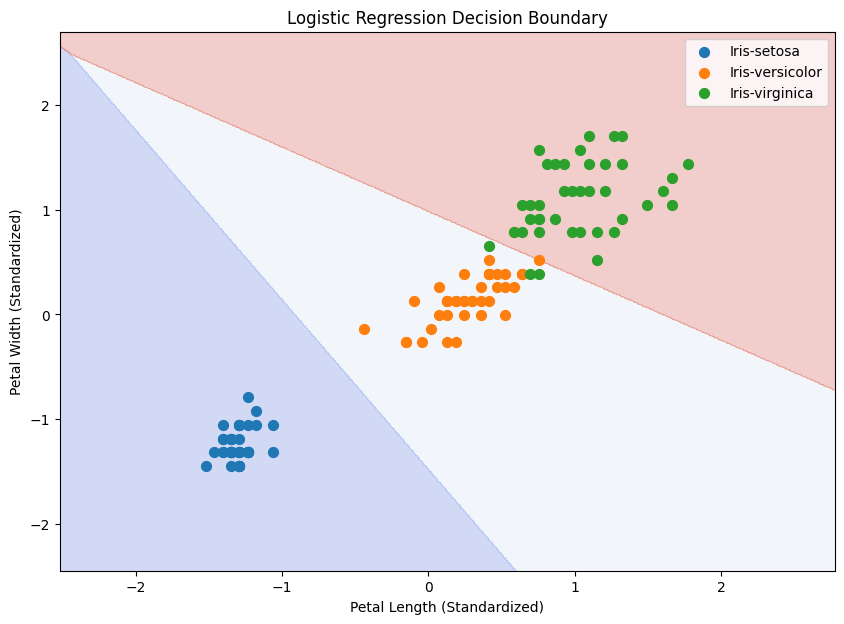

In [ ]:
# Create Logistic Regression model
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train Logistic Regression
logistic_model.fit(X_train_2d_scaled, y_train_2d)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test_2d_scaled)

# Calculate accuracy
logistic_accuracy = accuracy_score(
    y_test_2d,
    y_pred_logistic
)

print(
    "Logistic Regression Accuracy: {:.2f}%".format(
        logistic_accuracy * 100
    )
)

# Predict the mesh points
Z_logistic = logistic_model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z_logistic = np.array([
    list(logistic_model.classes_).index(i)
    for i in Z_logistic
])

Z_logistic = Z_logistic.reshape(xx.shape)

# Plot
plt.figure(figsize=(10, 7))

plt.contourf(
    xx,
    yy,
    Z_logistic,
    alpha=0.25,
    cmap=plt.cm.coolwarm
)

# Plot data points
for species in logistic_model.classes_:
    mask = y_train_2d == species

    plt.scatter(
        X_train_2d_scaled[mask, 0],
        X_train_2d_scaled[mask, 1],
        s=50,
        label=species
    )

plt.xlabel("Petal Length (Standardized)")
plt.ylabel("Petal Width (Standardized)")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()



# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

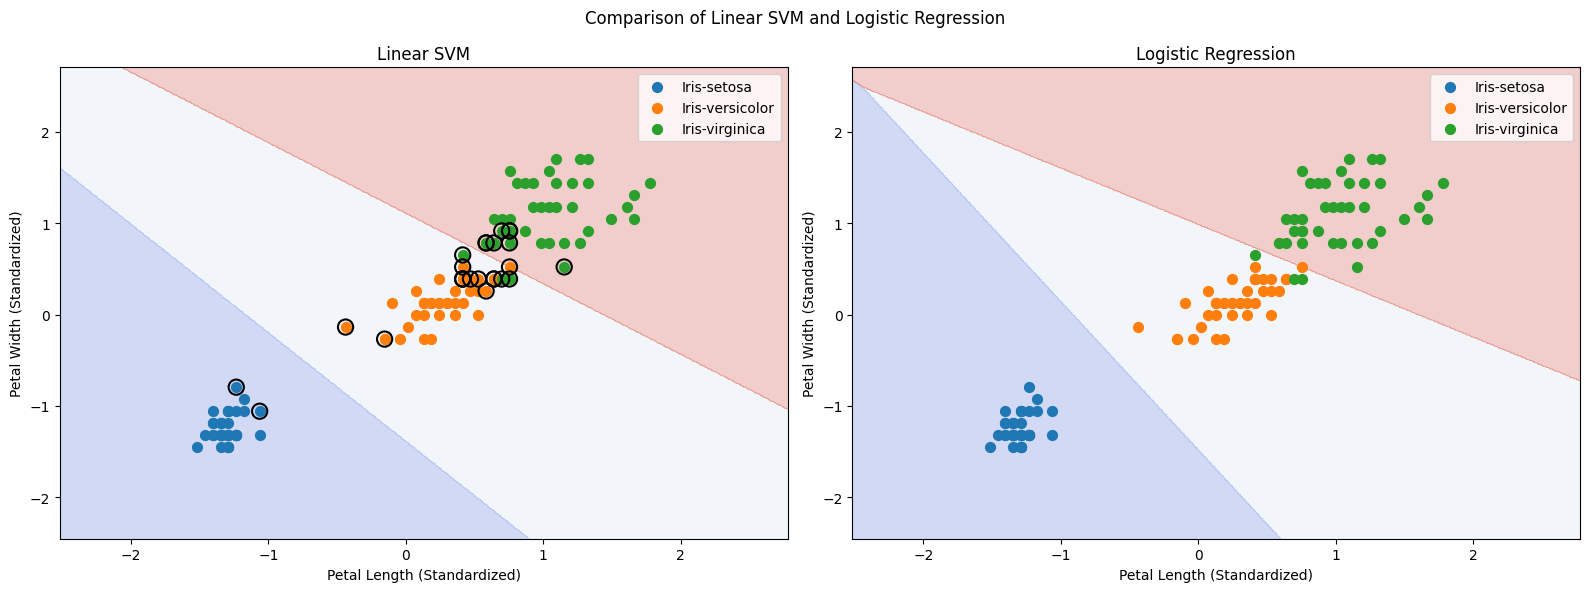

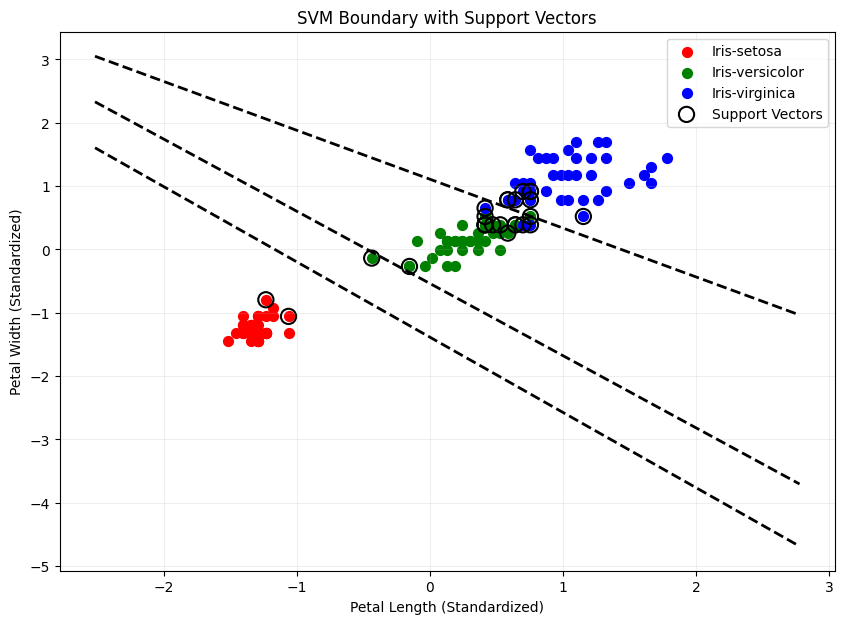

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---------------- SVM ----------------
axes[0].contourf(
    xx,
    yy,
    Z,
    alpha=0.25,
    cmap=plt.cm.coolwarm
)

for species in svm_2d.classes_:
    mask = y_train_2d == species

    axes[0].scatter(
        X_train_2d_scaled[mask, 0],
        X_train_2d_scaled[mask, 1],
        s=50,
        label=species
    )

axes[0].scatter(
    svm_2d.support_vectors_[:, 0],
    svm_2d.support_vectors_[:, 1],
    s=120,
    facecolors="none",
    edgecolors="black",
    linewidths=1.5
)

axes[0].set_title("Linear SVM")
axes[0].set_xlabel("Petal Length (Standardized)")
axes[0].set_ylabel("Petal Width (Standardized)")
axes[0].legend()


# ---------------- Logistic Regression ----------------
axes[1].contourf(
    xx,
    yy,
    Z_logistic,
    alpha=0.25,
    cmap=plt.cm.coolwarm
)

for species in logistic_model.classes_:
    mask = y_train_2d == species

    axes[1].scatter(
        X_train_2d_scaled[mask, 0],
        X_train_2d_scaled[mask, 1],
        s=50,
        label=species
    )

axes[1].set_title("Logistic Regression")
axes[1].set_xlabel("Petal Length (Standardized)")
axes[1].set_ylabel("Petal Width (Standardized)")
axes[1].legend()

plt.suptitle("Comparison of Linear SVM and Logistic Regression")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 7))

# Plot data
colors = ["red", "green", "blue"]

for species, color in zip(svm_2d.classes_, colors):
    mask = y_train_2d == species

    plt.scatter(
        X_train_2d_scaled[mask, 0],
        X_train_2d_scaled[mask, 1],
        color=color,
        label=species,
        s=50
    )

# SVM decision boundaries
x_values = np.linspace(
    X_train_2d_scaled[:, 0].min() - 1,
    X_train_2d_scaled[:, 0].max() + 1,
    500
)

# For multiclass SVM, plot pairwise decision boundaries
for coef, intercept in zip(svm_2d.coef_, svm_2d.intercept_):
    if abs(coef[1]) > 1e-10:
        y_values = -(coef[0] * x_values + intercept) / coef[1]
        plt.plot(
            x_values,
            y_values,
            "k--",
            linewidth=2
        )

# Support vectors
plt.scatter(
    svm_2d.support_vectors_[:, 0],
    svm_2d.support_vectors_[:, 1],
    s=120,
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    label="Support Vectors"
)

plt.xlabel("Petal Length (Standardized)")
plt.ylabel("Petal Width (Standardized)")
plt.title("SVM Boundary with Support Vectors")
plt.legend()
plt.grid(alpha=0.2)
plt.show()



# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

Performance Comparison
----------------------------------------
Linear SVM Accuracy       : 93.33%
Logistic Regression Accuracy: 93.33%


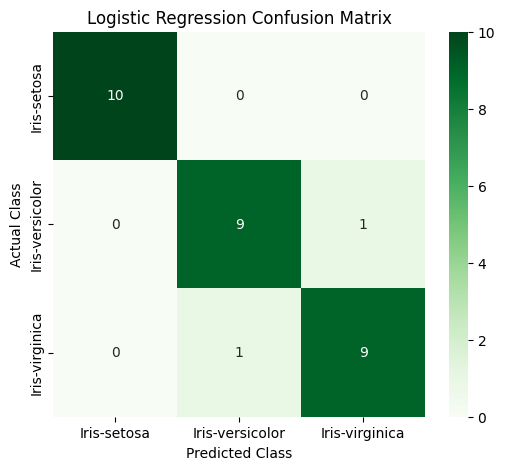

Logistic Regression Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



,Classifier,Accuracy,Accuracy (%)
0,Linear SVM,0.933333,93.333333
1,Logistic Regression,0.933333,93.333333


RBF SVM Accuracy: 93.33%


In [ ]:
print("Performance Comparison")
print("-" * 40)

print(
    "Linear SVM Accuracy       : {:.2f}%".format(
        accuracy_score(y_test_2d, y_pred_2d_svm) * 100
    )
)

print(
    "Logistic Regression Accuracy: {:.2f}%".format(
        accuracy_score(y_test_2d, y_pred_logistic) * 100
    )
)


cm_logistic = confusion_matrix(
    y_test_2d,
    y_pred_logistic
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=logistic_model.classes_,
    yticklabels=logistic_model.classes_
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()


print("Logistic Regression Classification Report:")
print(
    classification_report(
        y_test_2d,
        y_pred_logistic
    )
)


comparison = pd.DataFrame({
    "Classifier": [
        "Linear SVM",
        "Logistic Regression"
    ],
    "Accuracy": [
        accuracy_score(y_test_2d, y_pred_2d_svm),
        accuracy_score(y_test_2d, y_pred_logistic)
    ]
})

comparison["Accuracy (%)"] = comparison["Accuracy"] * 100

display(comparison)




# RBF SVM
rbf_svm = SVC(
    kernel="rbf",
    random_state=42
)

rbf_svm.fit(X_train_2d_scaled, y_train_2d)

y_pred_rbf = rbf_svm.predict(X_test_2d_scaled)

print(
    "RBF SVM Accuracy: {:.2f}%".format(
        accuracy_score(y_test_2d, y_pred_rbf) * 100
    )
)




# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.